In [2]:
# 1. IMPORT LIBRARIES

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# 2. LOAD DATASET
df = pd.read_csv("diabetes_risk.csv")

print("Dataset Shape:", df.shape)
display(df.head())
print("\nDataset Information:")
df.info()

Dataset Shape: (15000, 19)


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-nul

## 2. PREPROCESSING — MISSING VALUES, DUPLICATES, ID & OUTLIERS

This is the **second major step after loading the dataset**. Missing values, duplicate rows, the identifier column, and numerical outliers are handled here. To reduce data leakage, learned preprocessing quantities are calculated from the training data only.

In [ ]:
# 2A. INITIAL PREPROCESSING CHECK

print("Original shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())

missing_before = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)})

print("\nMissing values BEFORE treatment:")
display(missing_before[missing_before["Missing Values"] > 0]
        .sort_values("Missing Values", ascending=False))

# Remove exact duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Remove identifier
df = df.drop(columns=["patient_id"])

print("\nShape after duplicate and ID handling:", df.shape)


Original shape: (15000, 19)
Duplicate rows: 0

Missing values BEFORE treatment:


,Missing Values,Missing %
alcohol_consumption,3788,25.25
smoking_status,472,3.15
income_bracket,463,3.09



Shape after duplicate and ID handling: (15000, 18)


In [4]:
# 2B. TRAIN / TEST SPLIT

X = df.drop(columns=["diabetes_risk"])
y = df["diabetes_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (12000, 18)
Testing shape: (3000, 18)


In [5]:
# 2C. TREAT MISSING VALUES
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()

# Fit imputers ONLY on training data
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols, index=X_train.index)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[numeric_cols]),
    columns=numeric_cols, index=X_test.index)

X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_train[categorical_cols]),
    columns=categorical_cols, index=X_train.index)

X_test_cat = pd.DataFrame(
    cat_imputer.transform(X_test[categorical_cols]),
    columns=categorical_cols, index=X_test.index)

X_train_clean = pd.concat([X_train_num, X_train_cat], axis=1)[X_train.columns]
X_test_clean = pd.concat([X_test_num, X_test_cat], axis=1)[X_test.columns]

print("Total missing values in training data after treatment:", X_train_clean.isnull().sum().sum())
print("Total missing values in test data after treatment:", X_test_clean.isnull().sum().sum())

print("\nMissing-value check after treatment:")
display(pd.DataFrame({
    "Train Missing": X_train_clean.isnull().sum(),
    "Test Missing": X_test_clean.isnull().sum()}))

Total missing values in training data after treatment: 0
Total missing values in test data after treatment: 0

Missing-value check after treatment:


,Train Missing,Test Missing
patient_id,0,0
age,0,0
gender,0,0
city,0,0
bmi,0,0
family_history_diabetes,0,0
physical_activity_level,0,0
diet_type,0,0
smoking_status,0,0
alcohol_consumption,0,0


### Missing values have now been treated.

The imputers are fitted only on the training data and then applied to the test data. The next subsection performs outlier detection using training-data IQR thresholds and documents the treatment decision.

### 2D. Outlier Detection & Treatment

Outliers are detected **after missing-value treatment** using the IQR rule on the **training data only**. The training-set quartiles define the lower and upper bounds, which are then used to inspect both training and test data without learning thresholds from the test set.

For this healthcare dataset, IQR flags are treated as **potential outliers, not automatic errors**. Values such as high fasting blood sugar, HbA1c, BMI, blood pressure, and waist circumference can be clinically meaningful. Therefore, plausible values are **retained rather than deleted or capped blindly**. This avoids removing high-risk observations that may be important for diabetes classification.

**Treatment decision:** retain all IQR-flagged observations unless a value is impossible, inconsistent, or confirmed as a data-entry error. No rows are removed solely because they cross an IQR boundary.

IQR-based outlier summary (bounds learned from training data):


,Feature,Lower Bound,Upper Bound,Train Outliers,Train Outlier %,Test Outliers,Test Outlier %
0,fasting_blood_sugar,79.00,255.00,344,2.87,88,2.93
1,hba1c_level,4.80,8.80,285,2.38,70,2.33
2,hours_sleep_per_night,4.75,9.95,282,2.35,78,2.60
3,blood_pressure_diastolic,65.00,105.00,171,1.42,42,1.40
4,waist_circumference_cm,71.09,128.39,139,1.16,37,1.23
5,bmi,12.10,33.70,126,1.05,35,1.17
6,blood_pressure_systolic,100.00,180.00,8,0.07,3,0.10
7,age,17.00,73.00,2,0.02,1,0.03
8,stress_level,-0.50,11.50,0,0.00,0,0.00


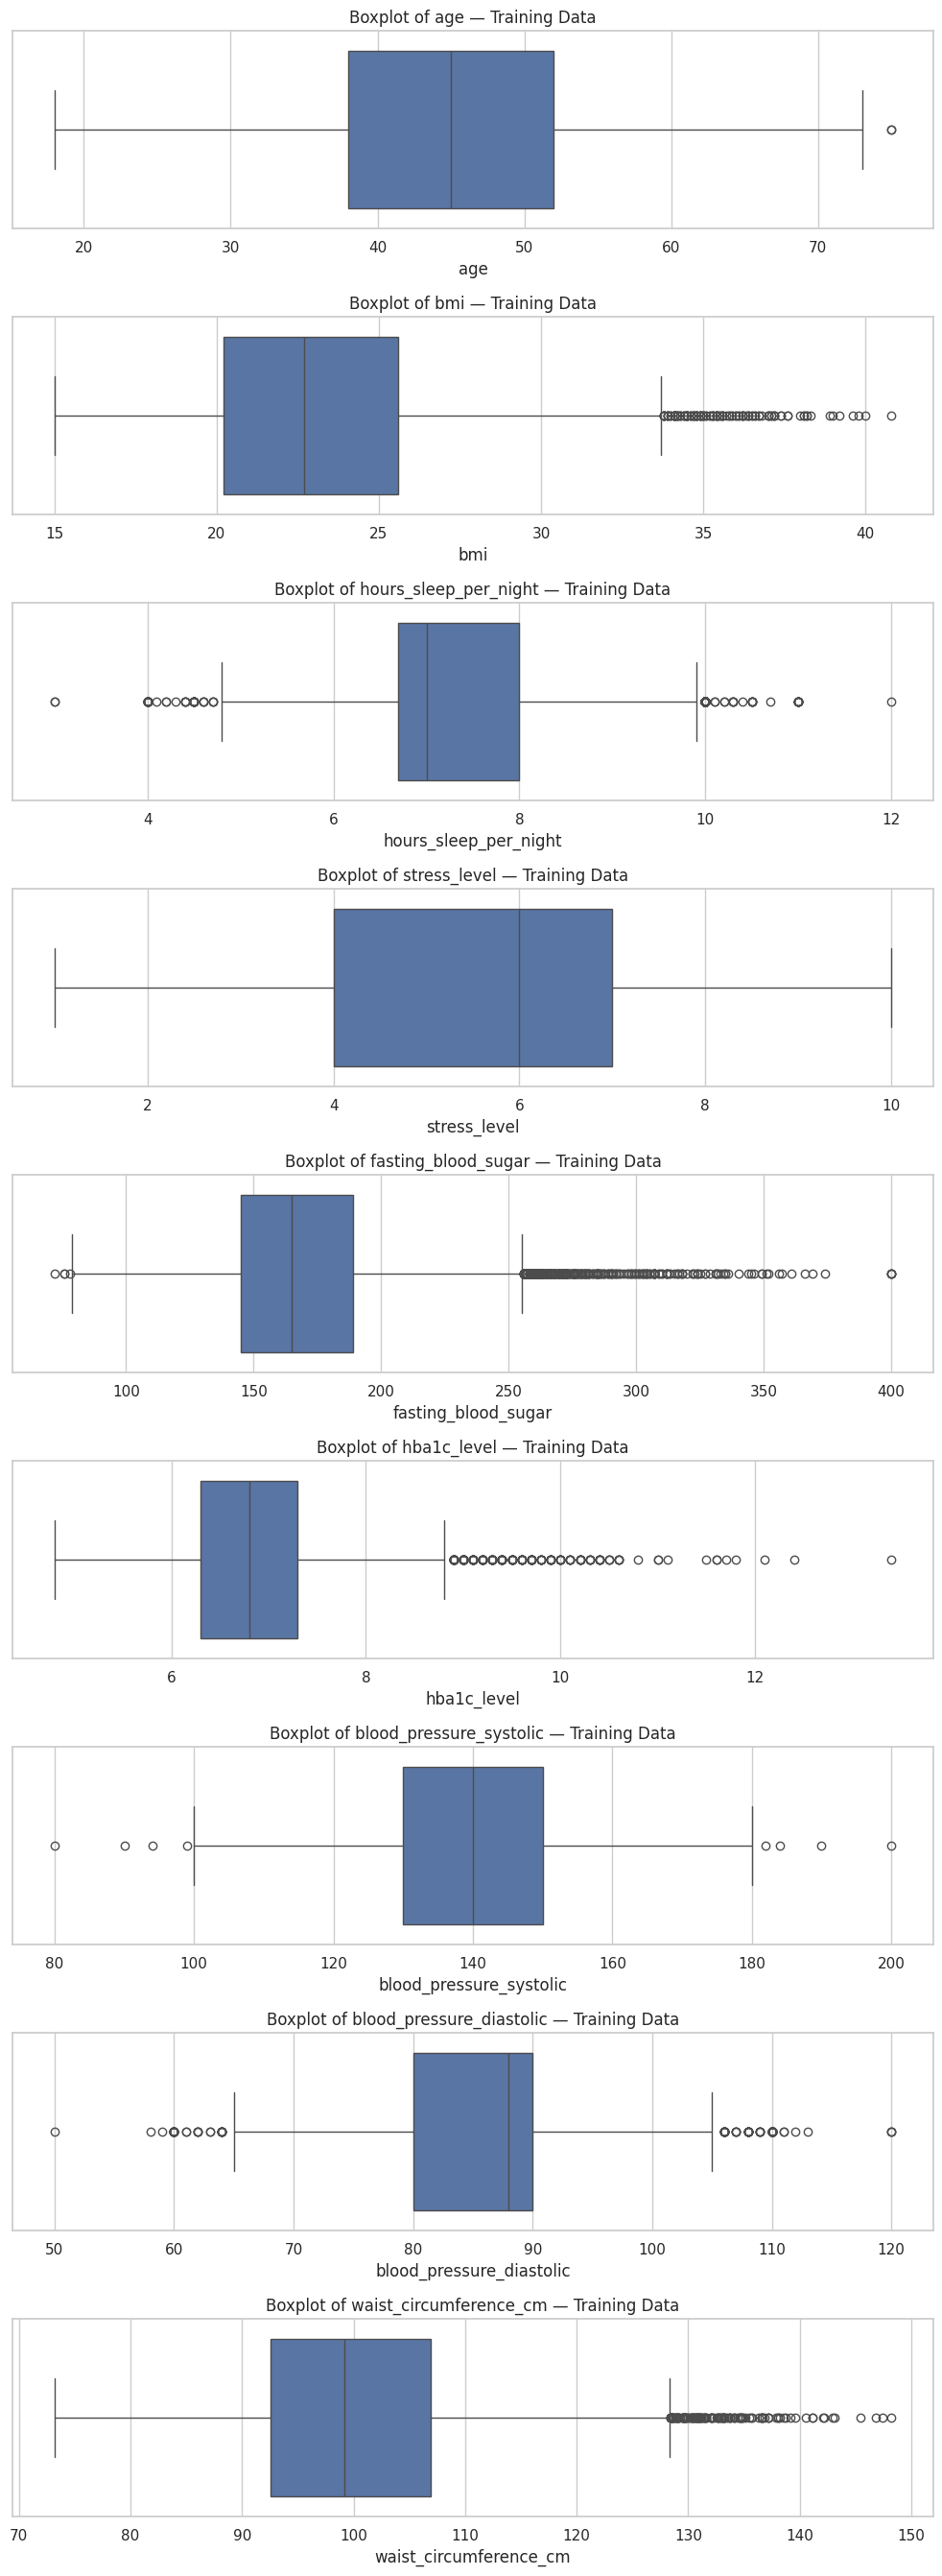


Outlier treatment decision:
Retained plausible extreme clinical values; no automatic deletion or capping was applied.
Training rows retained: 12000 of 12000
Testing rows retained: 3000 of 3000


In [ ]:
# 2D. OUTLIER DETECTION & TREATMENT
# Detect outliers with IQR thresholds learned ONLY from the training data.
# IQR flags are not automatically removed because extreme clinical values
# may contain important information for diabetes-risk classification.

outlier_rows = []
outlier_bounds = {}

for col in numeric_cols:
    q1 = X_train_clean[col].quantile(0.25)
    q3 = X_train_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_bounds[col] = (lower_bound, upper_bound)

    train_mask = (X_train_clean[col] < lower_bound) | (X_train_clean[col] > upper_bound)
    test_mask = (X_test_clean[col] < lower_bound) | (X_test_clean[col] > upper_bound)

    outlier_rows.append({
        'Feature': col,
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Train Outliers': int(train_mask.sum()),
        'Train Outlier %': round(train_mask.mean() * 100, 2),
        'Test Outliers': int(test_mask.sum()),
        'Test Outlier %': round(test_mask.mean() * 100, 2)})

outlier_summary = (
    pd.DataFrame(outlier_rows)
    .sort_values('Train Outlier %', ascending=False)
    .reset_index(drop=True))

print('IQR-based outlier summary (bounds learned from training data):')
display(outlier_summary)

# Visual inspection of numerical variables after missing-value treatment
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 3 * len(numeric_cols)))
if len(numeric_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=X_train_clean[col], ax=ax)
    ax.set_title(f'Boxplot of {col} — Training Data')
plt.tight_layout()
plt.show()

# Treatment decision: retain plausible IQR-flagged observations.
# No rows are removed or capped solely because of the IQR rule.
X_train_treated = X_train_clean.copy()
X_test_treated = X_test_clean.copy()

print('\nOutlier treatment decision:')
print('Retained plausible extreme clinical values; no automatic deletion or capping was applied.')
print('Training rows retained:', len(X_train_treated), 'of', len(X_train_clean))
print('Testing rows retained:', len(X_test_treated), 'of', len(X_test_clean))


## 3. EXPLORATORY DATA ANALYSIS (EDA)

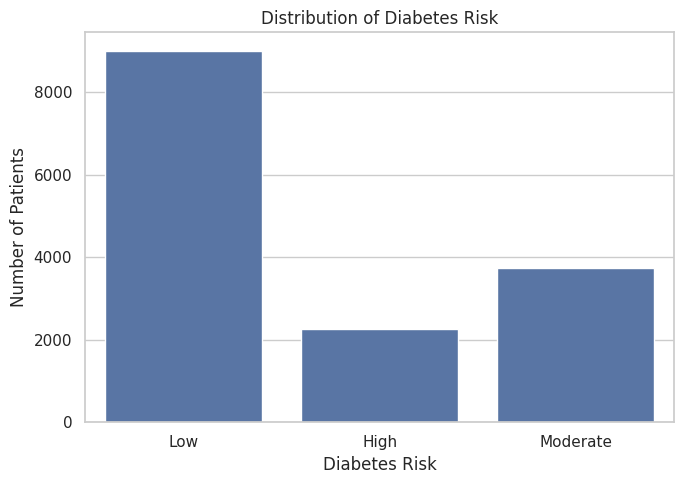

In [6]:
# 6. TARGET DISTRIBUTION

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="diabetes_risk")
plt.title("Distribution of Diabetes Risk")
plt.xlabel("Diabetes Risk")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

In [7]:
# 4. UNIQUE VALUES / CATEGORIES

for col in df.columns:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique(dropna=True))
    print(df[col].dropna().unique()[:15])


patient_id
Unique values: 15000
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]

age
Unique values: 58
[47 53 41 57 58 42 44 51 38 22 26 46 49 37 40]

gender
Unique values: 3
['Female' 'Male' 'Other']

city
Unique values: 18
['Mumbai' 'Thane' 'Bengaluru' 'Hyderabad' 'Delhi' 'Kolkata' 'Ahmedabad'
 'Pune' 'Chennai' 'Kanpur' 'Bhopal' 'Visakhapatnam' 'Patna' 'Jaipur'
 'Surat']

bmi
Unique values: 239
[26.5 20.5 31.3 22.8 16.7 22.  22.5 19.5 20.3 24.1 21.5 23.3 19.3 15.
 21.4]

family_history_diabetes
Unique values: 2
['Yes' 'No']

physical_activity_level
Unique values: 3
['Sedentary' 'Moderate' 'Active']

diet_type
Unique values: 4
['Vegetarian' 'Non-Vegetarian' 'Pescatarian' 'Vegan']

smoking_status
Unique values: 3
['Never' 'Current' 'Former']

alcohol_consumption
Unique values: 3
['Never' 'Regular' 'Occasional']

hours_sleep_per_night
Unique values: 73
[ 9.   7.   6.5  6.9  6.   4.8  6.2 10.   8.9  8.   7.6  7.9  6.3  5.3
  8.1]

stress_level
Unique values: 10
[ 8  6  7  5 10  2  4  9  

In [ ]:
# 7. NUMERICAL SUMMARY

numeric_all = df.select_dtypes(include=np.number).columns.tolist()
display(df[numeric_all].describe().T)

# Outlier detection and the treatment decision were completed in Step 2D.
display(outlier_summary)


,count,mean,std,min,25%,50%,75%,max
age,15000.0,44.333667,10.383753,18.0,38.0,45.0,52.0,80.0
bmi,15000.0,23.062260,4.046391,15.0,20.1,22.7,25.6,40.8
hours_sleep_per_night,15000.0,7.309860,1.109372,3.0,6.7,7.0,8.0,12.0
stress_level,15000.0,5.941200,2.148406,1.0,4.0,6.0,7.0,10.0
fasting_blood_sugar,15000.0,168.789933,38.365822,72.0,145.0,165.0,189.0,400.0
hba1c_level,15000.0,6.878387,0.843276,4.8,6.3,6.8,7.3,13.4
blood_pressure_systolic,15000.0,139.496200,12.660785,80.0,130.0,140.0,150.0,200.0
blood_pressure_diastolic,15000.0,86.256933,8.386529,50.0,80.0,88.0,90.0,120.0
waist_circumference_cm,15000.0,100.207933,10.760331,73.2,92.5,99.3,106.9,148.2


,Feature,Lower Bound,Upper Bound,Train Outliers,Train Outlier %,Test Outliers,Test Outlier %
0,fasting_blood_sugar,79.00,255.00,344,2.87,88,2.93
1,hba1c_level,4.80,8.80,285,2.38,70,2.33
2,hours_sleep_per_night,4.75,9.95,282,2.35,78,2.60
3,blood_pressure_diastolic,65.00,105.00,171,1.42,42,1.40
4,waist_circumference_cm,71.09,128.39,139,1.16,37,1.23
5,bmi,12.10,33.70,126,1.05,35,1.17
6,blood_pressure_systolic,100.00,180.00,8,0.07,3,0.10
7,age,17.00,73.00,2,0.02,1,0.03
8,stress_level,-0.50,11.50,0,0.00,0,0.00


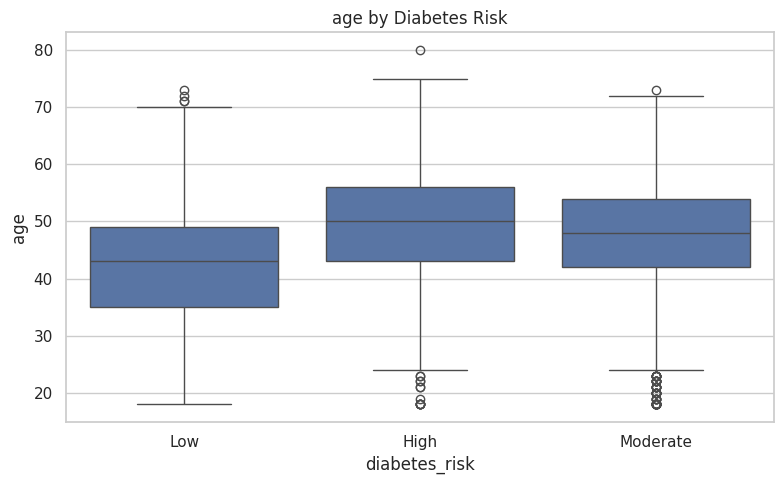

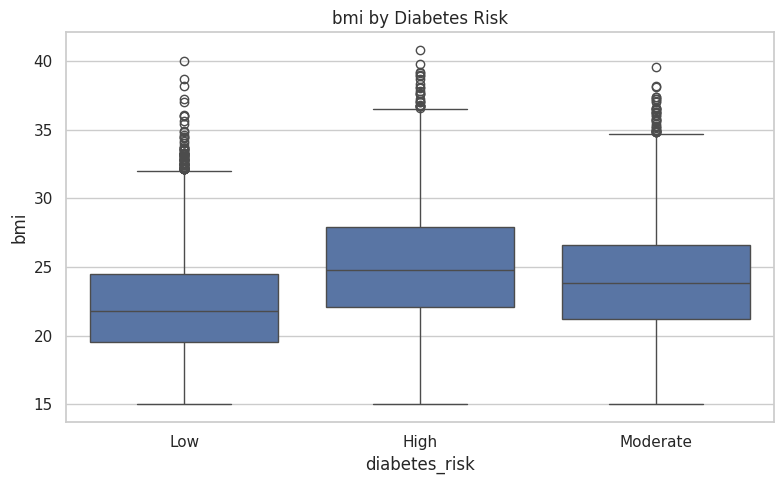

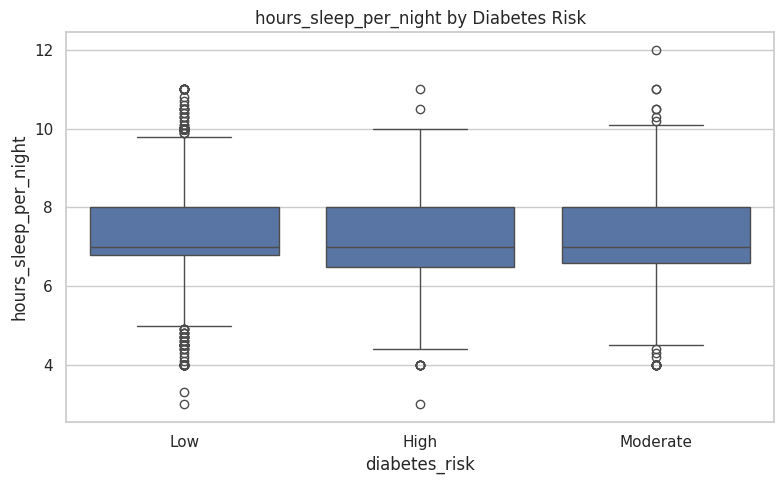

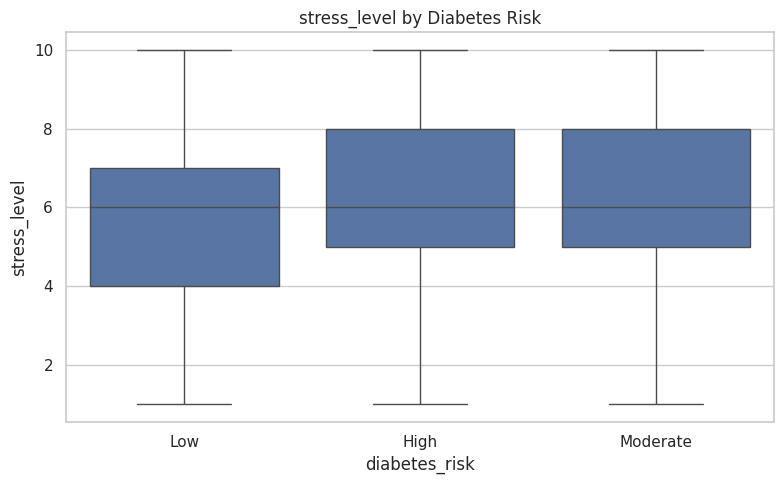

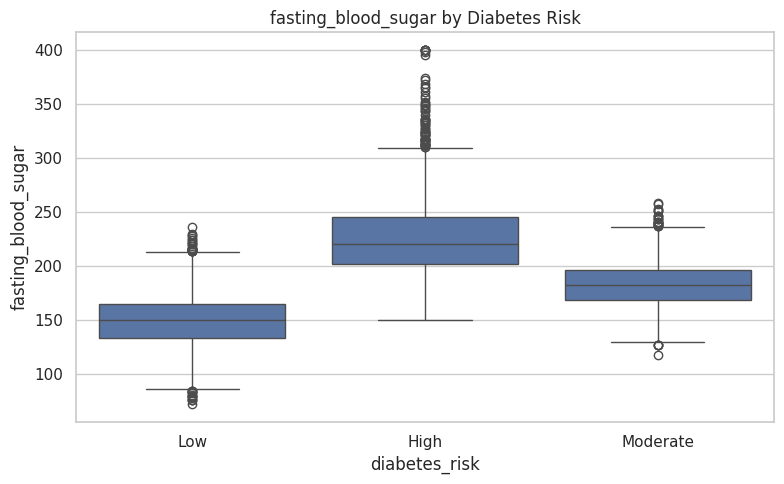

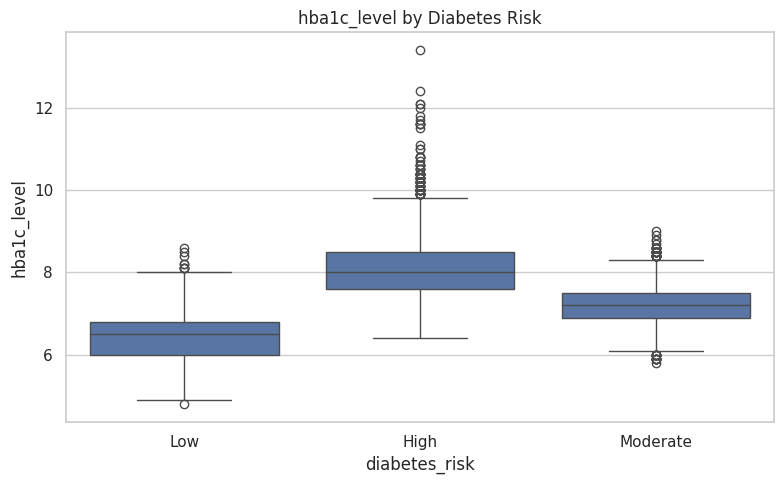

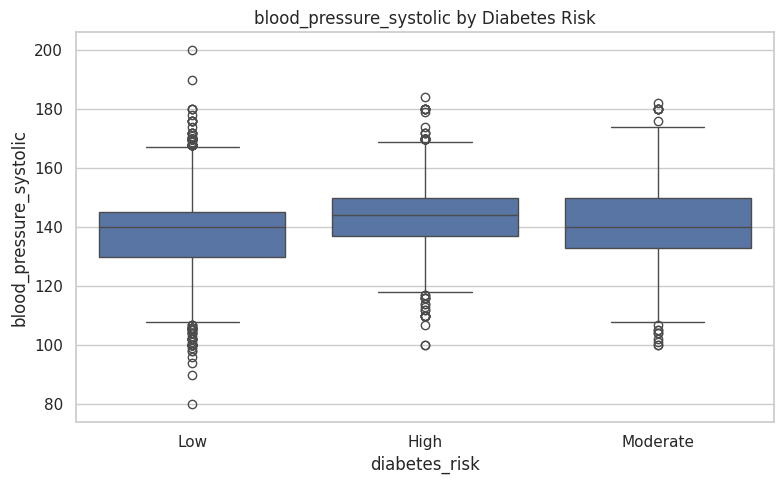

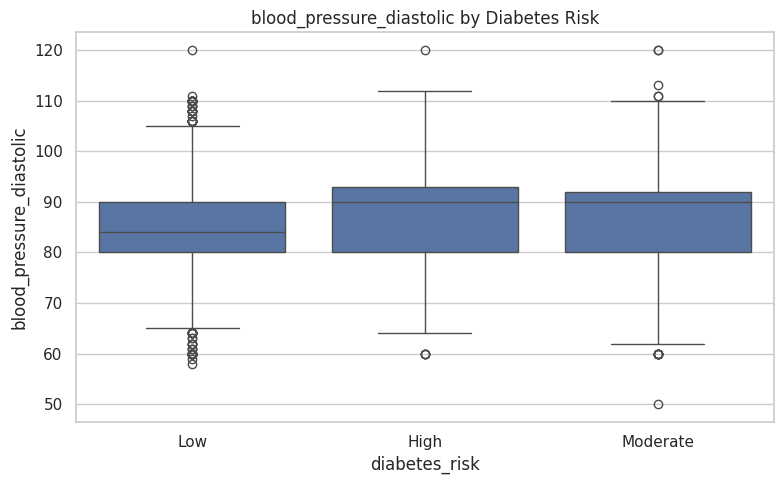

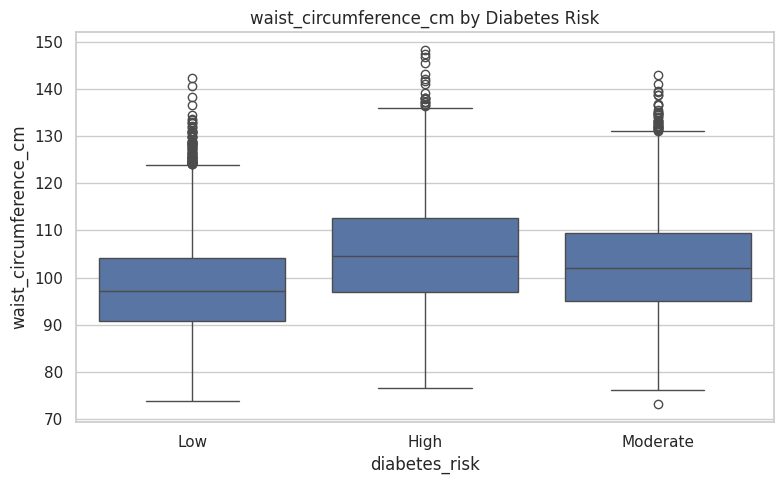

In [ ]:
# 8. NUMERICAL VARIABLES VS TARGET

for col in numeric_all:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="diabetes_risk", y=col)
    plt.title(f"{col} by Diabetes Risk")
    plt.tight_layout()
    plt.show()

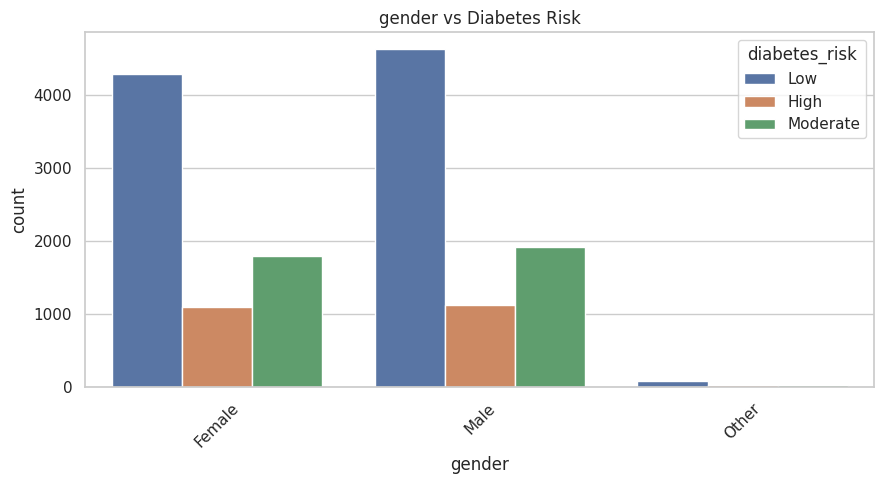

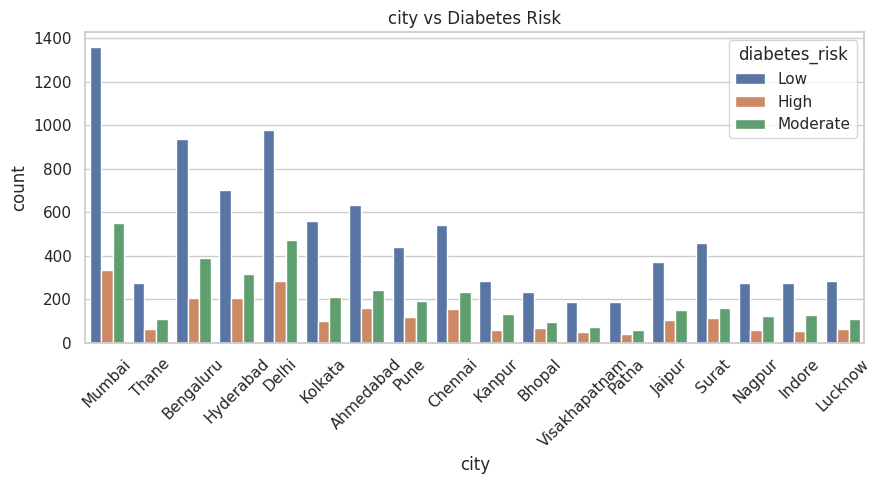

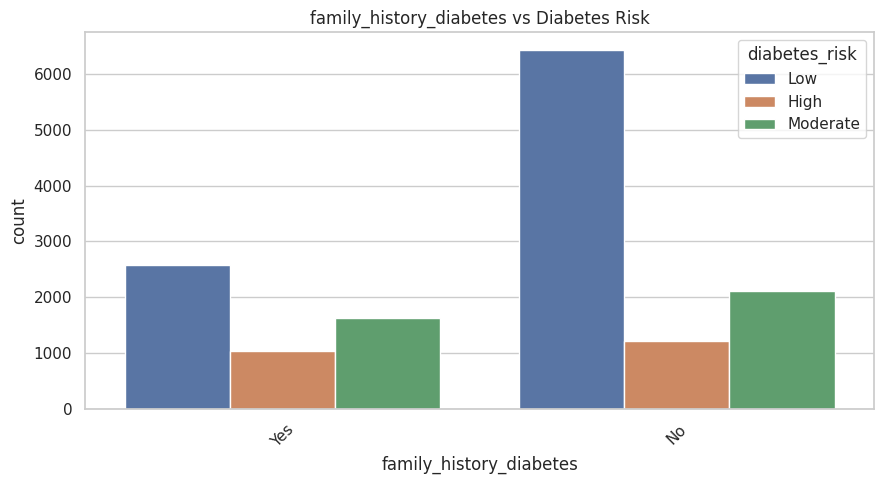

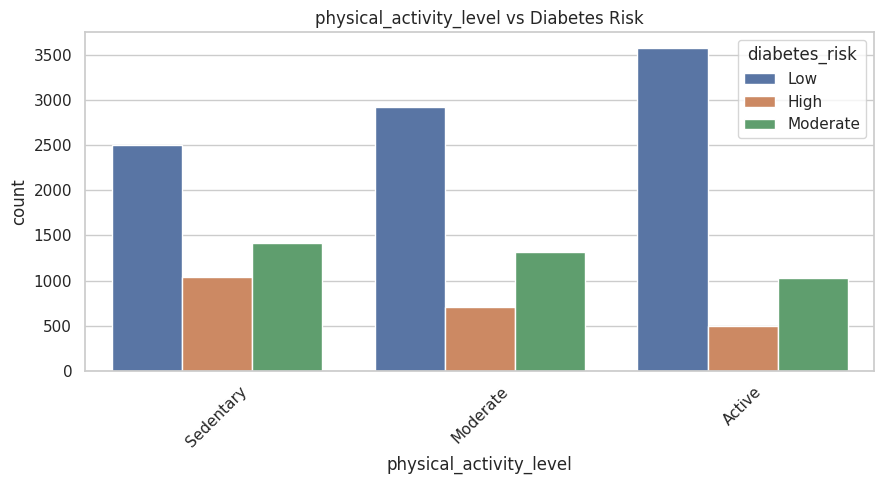

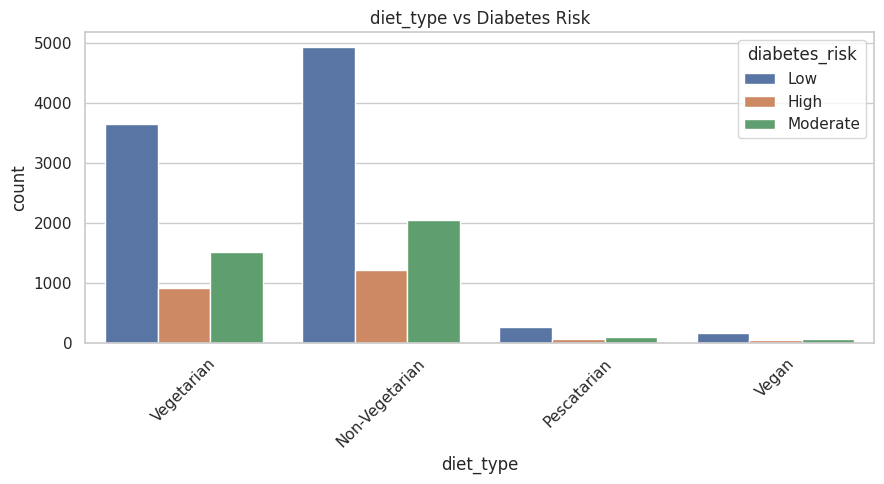

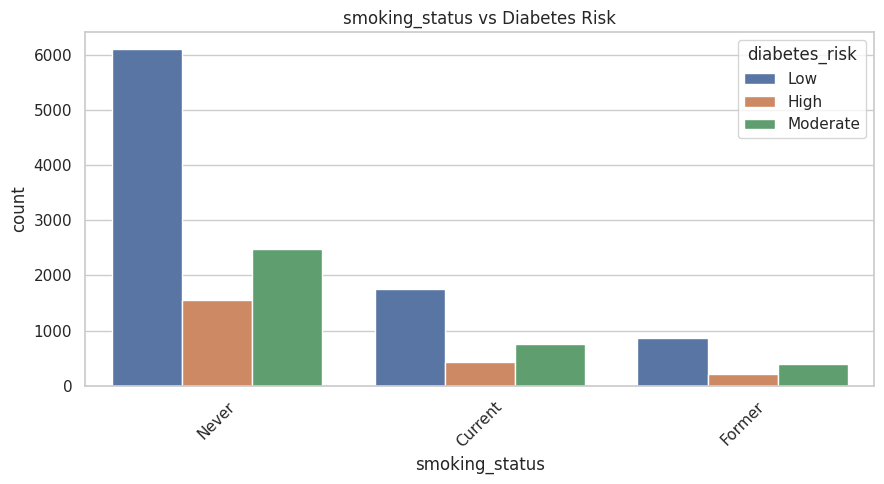

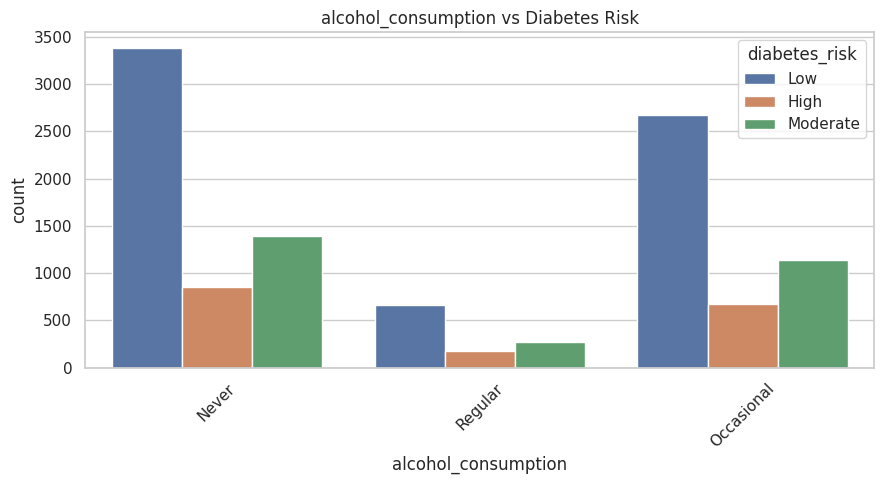

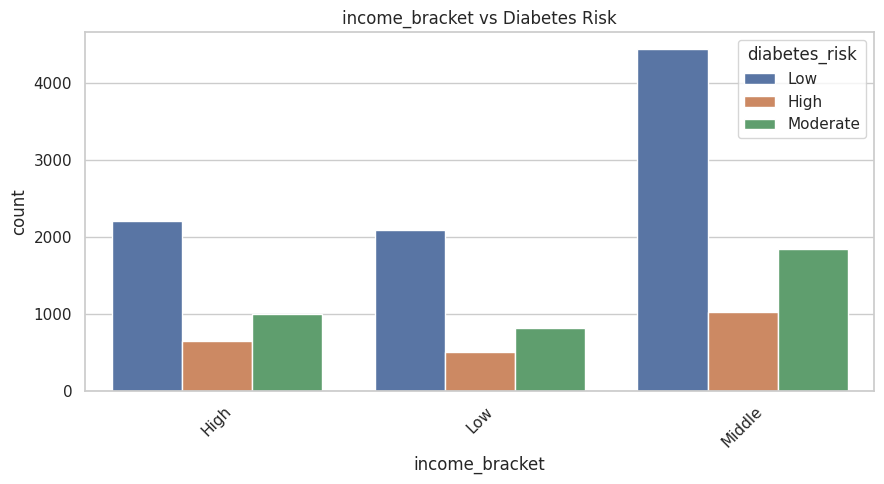

In [ ]:
# 9. CATEGORICAL VARIABLES VS TARGET

categorical_all = df.select_dtypes(include="object").columns.tolist()
categorical_predictors = [c for c in categorical_all if c != "diabetes_risk"]

for col in categorical_predictors:
    plt.figure(figsize=(9, 5))
    sns.countplot(data=df, x=col, hue="diabetes_risk")
    plt.title(f"{col} vs Diabetes Risk")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 4. FEATURE SELECTION — TRAINING DATA ONLY

In [ ]:
# 11A. FEATURE TYPES
numeric_features = X_train_treated.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train_treated.select_dtypes(include="object").columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'bmi', 'hours_sleep_per_night', 'stress_level', 'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'waist_circumference_cm']

Categorical features:
['gender', 'city', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket']


In [ ]:
# 11B. ANOVA — NUMERICAL FEATURES

anova_results = []

for feature in numeric_features:
    groups = [
        X_train_treated.loc[y_train == cls, feature].dropna()
        for cls in sorted(y_train.unique())]
    f_stat, p_value = f_oneway(*groups)

    anova_results.append({
        "Feature": feature,
        "F-statistic": f_stat,
        "p-value": p_value})

anova_df = (
    pd.DataFrame(anova_results)
    .sort_values("p-value")
    .reset_index(drop=True))

display(anova_df)

,Feature,F-statistic,p-value
0,hba1c_level,7031.477747,0.000000e+00
1,fasting_blood_sugar,7309.082130,0.000000e+00
2,age,580.511286,2.250959e-241
3,bmi,539.550217,4.193492e-225
4,waist_circumference_cm,458.574375,1.228107e-192
5,blood_pressure_systolic,299.775971,9.070490e-128
6,blood_pressure_diastolic,187.329390,7.733676e-81
7,stress_level,60.295791,8.802462e-27
8,hours_sleep_per_night,8.945623,1.311775e-04


In [ ]:
# 11C. CHI-SQUARE — CATEGORICAL FEATURES

chi_results = []

for feature in categorical_features:
    contingency = pd.crosstab(
        X_train_treated[feature],
        y_train)

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    chi_results.append({
        "Feature": feature,
        "Chi-square": chi2,
        "p-value": p_value})

chi_df = (
    pd.DataFrame(chi_results)
    .sort_values("p-value")
    .reset_index(drop=True))

display(chi_df)

,Feature,Chi-square,p-value
0,family_history_diabetes,335.302398,1.548850e-73
1,physical_activity_level,328.016102,9.765929e-70
2,income_bracket,10.868351,2.808409e-02
3,city,42.938375,1.399333e-01
4,smoking_status,4.926487,2.949239e-01
5,diet_type,6.513813,3.681543e-01
6,alcohol_consumption,3.407153,4.921356e-01
7,gender,1.941585,7.465021e-01


In [ ]:
# 11D. SELECT FEATURES

alpha = 0.05

selected_numeric = anova_df.loc[
    anova_df["p-value"] < alpha, "Feature"].tolist()

selected_categorical = chi_df.loc[
    chi_df["p-value"] < alpha, "Feature"].tolist()

selected_features = selected_numeric + selected_categorical

print("Selected numerical features:")
print(selected_numeric)

print("\nSelected categorical features:")
print(selected_categorical)

print("\nFinal selected features:")
print(selected_features)
print("\nNumber of selected features:", len(selected_features))

Selected numerical features:
['hba1c_level', 'fasting_blood_sugar', 'age', 'bmi', 'waist_circumference_cm', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'stress_level', 'hours_sleep_per_night']

Selected categorical features:
['family_history_diabetes', 'physical_activity_level', 'income_bracket']

Final selected features:
['hba1c_level', 'fasting_blood_sugar', 'age', 'bmi', 'waist_circumference_cm', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'stress_level', 'hours_sleep_per_night', 'family_history_diabetes', 'physical_activity_level', 'income_bracket']

Number of selected features: 12


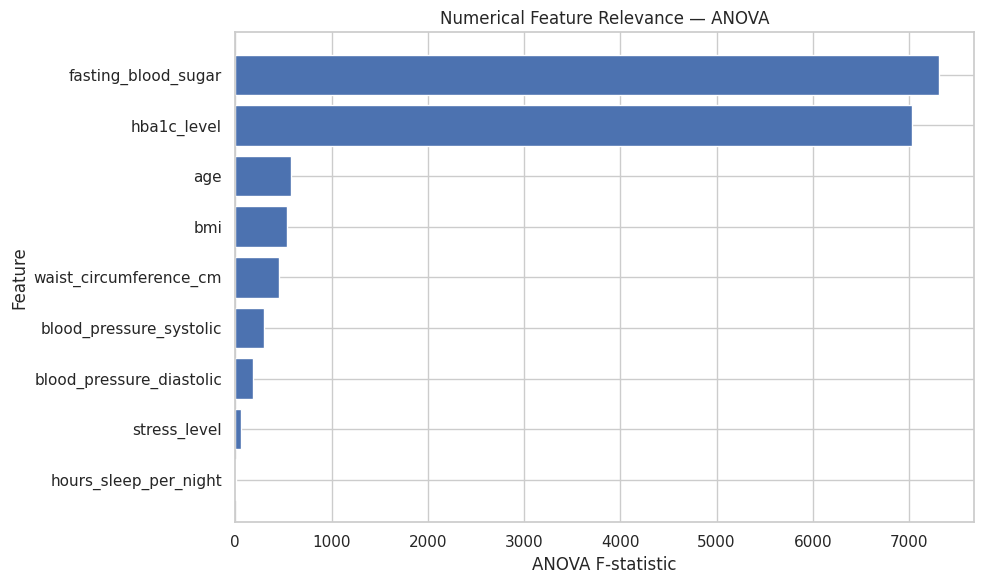

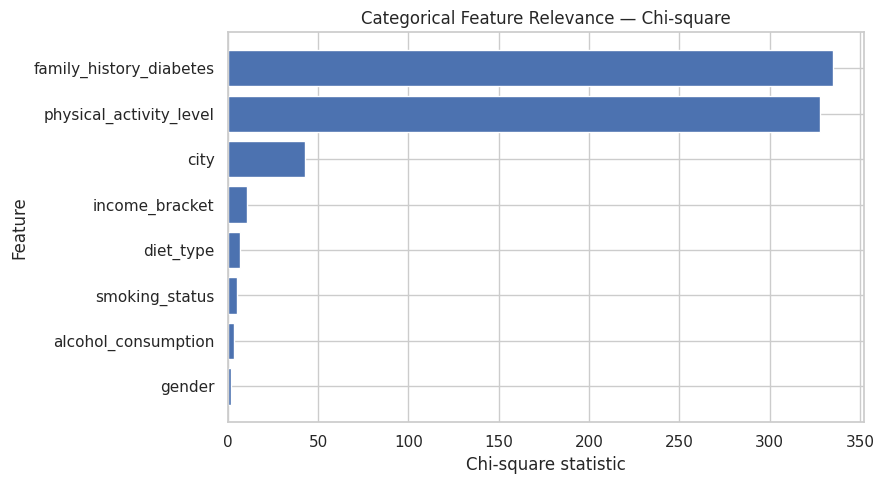

In [ ]:
# 11E. FEATURE SELECTION VISUALIZATION

plt.figure(figsize=(10, 6))
plot_df = anova_df.sort_values("F-statistic")
plt.barh(plot_df["Feature"], plot_df["F-statistic"])
plt.xlabel("ANOVA F-statistic")
plt.ylabel("Feature")
plt.title("Numerical Feature Relevance — ANOVA")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plot_chi = chi_df.sort_values("Chi-square")
plt.barh(plot_chi["Feature"], plot_chi["Chi-square"])
plt.xlabel("Chi-square statistic")
plt.ylabel("Feature")
plt.title("Categorical Feature Relevance — Chi-square")
plt.tight_layout()
plt.show()

## 5. MODELING PREPROCESSING PIPELINE

In [13]:
X_train_treated = X_train_clean.copy()
X_test_treated = X_test_clean.copy()

# Explicitly define selected_features, which should ideally come from previous cells.
selected_features = ['hba1c_level', 'fasting_blood_sugar', 'age', 'bmi', 'waist_circumference_cm', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'stress_level', 'hours_sleep_per_night', 'family_history_diabetes', 'physical_activity_level', 'income_bracket']

# 12. SELECTED DATA

X_train_selected = X_train_treated[selected_features].copy()
X_test_selected = X_test_treated[selected_features].copy()

selected_numeric = X_train_selected.select_dtypes(include=np.number).columns.tolist()
selected_categorical = X_train_selected.select_dtypes(include="object").columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, selected_numeric),
        ("cat", categorical_transformer, selected_categorical)])

print("Selected numerical features:", selected_numeric)
print("Selected categorical features:", selected_categorical)

Selected numerical features: ['hba1c_level', 'fasting_blood_sugar', 'age', 'bmi', 'waist_circumference_cm', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'stress_level', 'hours_sleep_per_night']
Selected categorical features: ['family_history_diabetes', 'physical_activity_level', 'income_bracket']


## 6. BASELINE MODEL BUILDING

Three classifiers are compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest

Because the target classes are imbalanced (`Low`, `Moderate`, `High`), `class_weight="balanced"` is used.

In [15]:
# 13. BASELINE MODELS

# Re-defining preprocessor and its components to ensure availability in case of kernel restart or out-of-order execution.
# These definitions are originally from cell 096e6684.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, selected_numeric),
        ("cat", categorical_transformer, selected_categorical)])

baseline_models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=3000,
            class_weight="balanced"))
        ]),

    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            max_depth=8
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        ))
    ])
}

baseline_results = []

for name, model in baseline_models.items():
    model.fit(X_train_selected, y_train)
    pred = model.predict(X_test_selected)

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_test, pred, average="weighted", zero_division=0)
    })

baseline_results_df = (
    pd.DataFrame(baseline_results)
    .sort_values("F1-Score", ascending=False)
    .reset_index(drop=True)
)

display(baseline_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.7823,0.7776,0.7823,0.7787
1,Logistic Regression,0.7687,0.7954,0.7687,0.7776
2,Decision Tree,0.7477,0.7760,0.7477,0.7574


## 7. HYPERPARAMETER OPTIMIZATION

Five-fold stratified cross-validation is used.  
The optimization metric is **weighted F1-score**, which is appropriate for this three-class problem with unequal class sizes.

In [16]:
# 14. GRID SEARCH

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

lr_grid = GridSearchCV(
    Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=3000,
            class_weight="balanced"
        ))
    ]),
    param_grid={
        "classifier__C": [0.1, 1, 10]
    },
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1
)

dt_grid = GridSearchCV(
    Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced"
        ))
    ]),
    param_grid={
        "classifier__max_depth": [5, 7, 10],
        "classifier__min_samples_leaf": [1, 2, 5]
    },
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1
)

rf_grid = GridSearchCV(
    Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]),
    param_grid={
        "classifier__n_estimators": [200, 300],
        "classifier__max_depth": [None, 15],
        "classifier__min_samples_leaf": [1, 2]
    },
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1
)

grid_searches = {
    "Logistic Regression": lr_grid,
    "Decision Tree": dt_grid,
    "Random Forest": rf_grid
}

for name, grid in grid_searches.items():
    print(f"Optimizing {name}...")
    grid.fit(X_train_selected, y_train)
    print("Best parameters:", grid.best_params_)
    print("Best CV weighted F1:", round(grid.best_score_, 4))
    print("-" * 60)

Optimizing Logistic Regression...
Best parameters: {'classifier__C': 10}
Best CV weighted F1: 0.7789
------------------------------------------------------------
Optimizing Decision Tree...
Best parameters: {'classifier__max_depth': 7, 'classifier__min_samples_leaf': 2}
Best CV weighted F1: 0.7573
------------------------------------------------------------
Optimizing Random Forest...
Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 300}
Best CV weighted F1: 0.7908
------------------------------------------------------------


In [17]:
# 15. OPTIMIZED MODEL EVALUATION

optimized_models = {
    name: grid.best_estimator_
    for name, grid in grid_searches.items()
}

optimized_results = []

for name, model in optimized_models.items():
    pred = model.predict(X_test_selected)
    prob = model.predict_proba(X_test_selected)

    optimized_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_test, pred, average="weighted", zero_division=0),
        "ROC-AUC": roc_auc_score(
            y_test, prob, multi_class="ovr", average="weighted"
        )
    })

optimized_results_df = (
    pd.DataFrame(optimized_results)
    .sort_values("F1-Score", ascending=False)
    .reset_index(drop=True)
)

display(optimized_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.7853,0.7903,0.7853,0.7873,0.9115
1,Logistic Regression,0.7693,0.7959,0.7693,0.7782,0.9133
2,Decision Tree,0.7433,0.7776,0.7433,0.7544,0.8863


In [19]:
# 16. BEFORE VS AFTER OPTIMIZATION

before = baseline_results_df[["Model", "F1-Score"]].rename(
    columns={"F1-Score": "Before F1"}
)

after = optimized_results_df[["Model", "F1-Score"]].rename(
    columns={"F1-Score": "After F1"}
)

comparison = before.merge(after, on="Model")
comparison["Improvement"] = comparison["After F1"] - comparison["Before F1"]

display(comparison.round(4))

,Model,Before F1,After F1,Improvement
0,Random Forest,0.7787,0.7873,0.0086
1,Logistic Regression,0.7776,0.7782,0.0006
2,Decision Tree,0.7574,0.7544,-0.0030


## 10. DETAILED FINAL EVALUATION

The test set has not been used for feature selection or hyperparameter tuning. It is used here only for final performance evaluation.

In [20]:
# 17. CLASSIFICATION REPORTS
for name, model in optimized_models.items():
    pred = model.predict(X_test_selected)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(
        y_test,
        pred,
        labels=["Low", "Moderate", "High"],
        zero_division=0
    ))


Logistic Regression
              precision    recall  f1-score   support

         Low       0.92      0.80      0.86      1800
    Moderate       0.53      0.67      0.59       750
        High       0.74      0.80      0.77       450

    accuracy                           0.77      3000
   macro avg       0.73      0.76      0.74      3000
weighted avg       0.80      0.77      0.78      3000


Decision Tree
              precision    recall  f1-score   support

         Low       0.91      0.77      0.84      1800
    Moderate       0.50      0.66      0.57       750
        High       0.72      0.77      0.74       450

    accuracy                           0.74      3000
   macro avg       0.71      0.73      0.71      3000
weighted avg       0.78      0.74      0.75      3000


Random Forest
              precision    recall  f1-score   support

         Low       0.88      0.87      0.88      1800
    Moderate       0.57      0.62      0.59       750
        High       0.79 

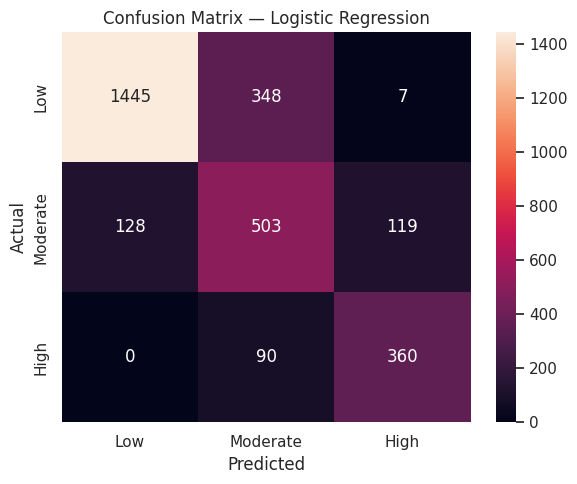

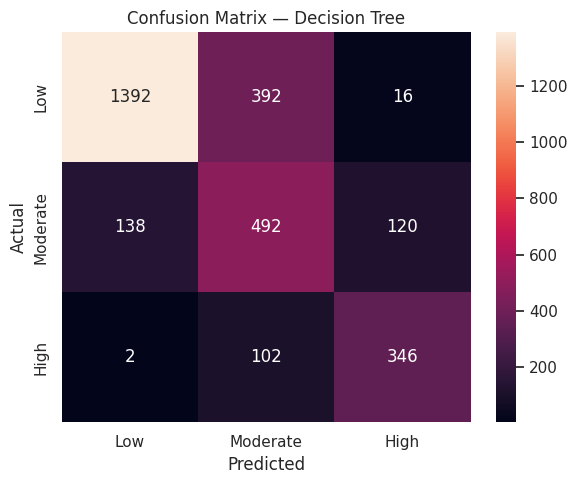

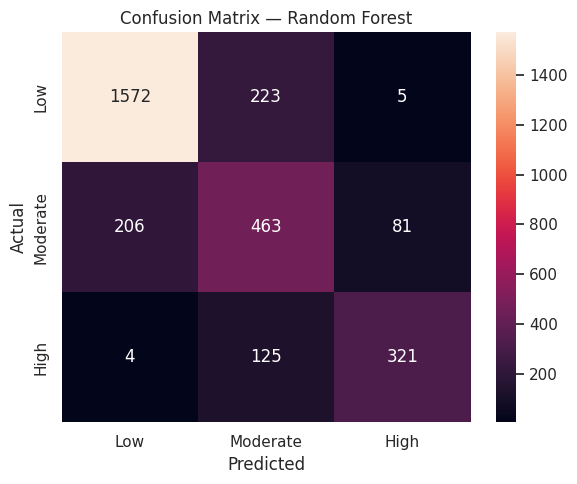

In [ ]:
# 18. CONFUSION MATRICES

class_labels = ["Low", "Moderate", "High"]

for name, model in optimized_models.items():
    pred = model.predict(X_test_selected)
    cm = confusion_matrix(y_test, pred, labels=class_labels)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [21]:
# 19. ROC-AUC — ONE-VS-REST

for name, model in optimized_models.items():
    prob = model.predict_proba(X_test_selected)

    weighted_auc = roc_auc_score(
        y_test,
        prob,
        multi_class="ovr",
        average="weighted"
    )

    print(f"{name} weighted ROC-AUC: {weighted_auc:.4f}")

Logistic Regression weighted ROC-AUC: 0.9133
Decision Tree weighted ROC-AUC: 0.8863
Random Forest weighted ROC-AUC: 0.9115


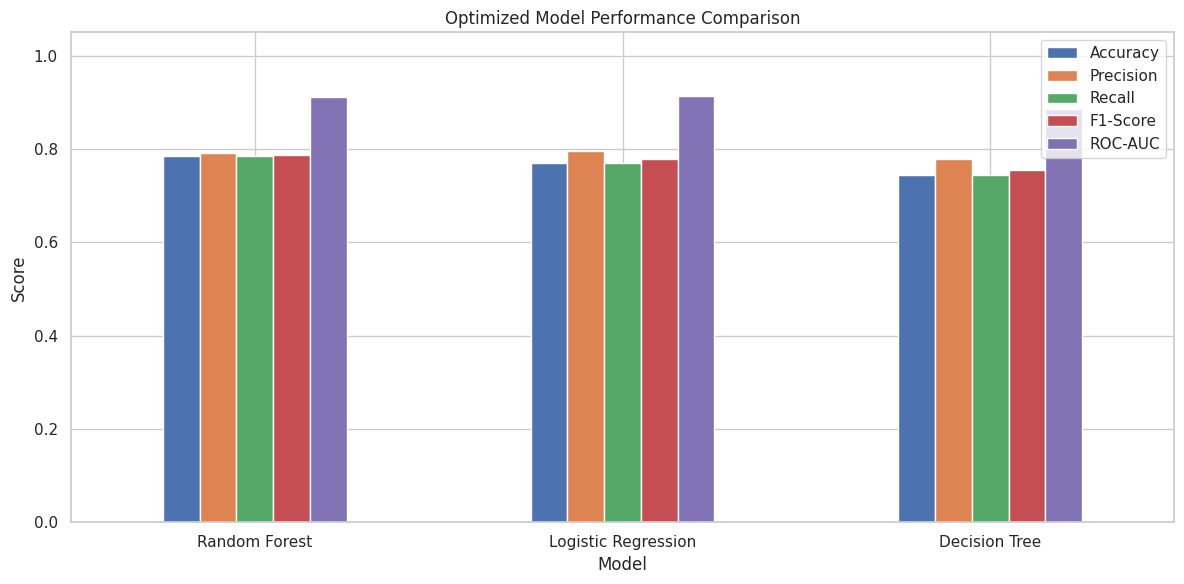

In [ ]:
# 20. MODEL COMPARISON

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

optimized_results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Optimized Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# 21. FINAL MODEL SELECTION

best_row = optimized_results_df.iloc[0]
best_model_name = best_row["Model"]
best_model = optimized_models[best_model_name]

print("BEST MODEL")
print("=" * 50)
print("Model:", best_model_name)
print("Accuracy:", round(best_row["Accuracy"], 4))
print("Precision:", round(best_row["Precision"], 4))
print("Recall:", round(best_row["Recall"], 4))
print("F1-Score:", round(best_row["F1-Score"], 4))
print("ROC-AUC:", round(best_row["ROC-AUC"], 4))

print("\nBest hyperparameters:")
print(grid_searches[best_model_name].best_params_)

BEST MODEL
Model: Random Forest
Accuracy: 0.7853
Precision: 0.7903
Recall: 0.7853
F1-Score: 0.7873
ROC-AUC: 0.9115

Best hyperparameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 300}


## 15. BUSINESS INSIGHTS AND RECOMMENDATIONS

This section translates the model results into actionable business insights based on the statistically selected predictors and the final model. Predictions should support—not replace—professional medical judgment.

### 15A. Interpret Key Predictors

- Numerical predictors with strong ANOVA significance differ across the Low, Moderate, and High risk groups.
- Significant Chi-square results indicate an association between categorical predictors and diabetes-risk category.
- For tree models, feature importance shows each encoded feature’s contribution to prediction. For Logistic Regression, larger absolute coefficients indicate stronger influence.
- Statistical association and model importance do not prove causation.

### 15B. Business Applications

1. **Risk-based segmentation:** Segment customers or program participants into Low, Moderate, and High-risk groups for differentiated follow-up.
2. **Prioritize high-risk cases:** Use High-risk predictions to prioritize screening reminders, wellness outreach, or referral workflows where appropriate.
3. **Targeted prevention:** Design focused nutrition, physical-activity, weight-management, and health-education programs for groups with greater predicted need.
4. **Resource allocation:** Prioritize limited staff time, screening capacity, and preventive-care resources toward higher predicted need.
5. **Early intervention:** Repeated predictions can help identify changes in risk and trigger earlier engagement when data are collected consistently.
6. **Data-driven planning:** Use aggregate risk patterns to support program and campaign planning rather than relying only on intuition.

### 15C. Limitations

- Performance may differ on a new population or organization because the dataset represents the population and data-generation process captured in this project.
- The model predicts Low, Moderate, or High risk; it does not diagnose diabetes.
- Missing information, including substantial missingness in `alcohol_consumption`, can introduce uncertainty through imputation.
- IQR-flagged extreme values were retained because plausible clinical extremes may be meaningful, but undetected data-entry errors can still affect performance.
- Class imbalance exists, so weighted metrics and balanced class weights were used; minority-class performance should still be monitored.
- ANOVA and Chi-square identify associations, not causal relationships.
- False positives and false negatives are possible, so predictions should be treated as decision-support signals.
- Privacy, fairness, consent, explainability, and applicable regulatory requirements should be assessed before deployment.

### 15D. Recommended Improvements

- Validate the model on an **external dataset** from another period, location, or organization.
- Monitor each risk class using class-specific precision, recall, and F1-score.
- Calibrate predicted probabilities to support better decision thresholds.
- Add explainability methods such as permutation importance or SHAP.
- Conduct fairness checks across relevant demographic groups.
- Compare additional algorithms such as Gradient Boosting or other calibrated ensemble approaches where appropriate.
- Implement data-quality, drift, and performance monitoring after deployment.
- Reassess features and hyperparameters as new observations become available.


## 16. FINAL CONCLUSION

The final model is selected using the highest **weighted F1-score** on the untouched test set.

### Key methodological corrections made

- `patient_id` is removed because it is only an identifier.
- Missing categorical values are imputed inside the pipeline.
- Numerical variables are scaled only within the pipeline.
- Categorical variables are one-hot encoded with `handle_unknown="ignore"`.
- The train/test split occurs **before feature selection**.
- ANOVA and Chi-square feature selection use **training data only**.
- Hyperparameter tuning uses **5-fold stratified cross-validation** on the training set.
- The test set is reserved for final evaluation.
- Multiple metrics are reported: Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Outliers are inspected rather than blindly deleted, because extreme health measurements may be meaningful observations.
